<a href="https://colab.research.google.com/github/santiaagoe/Natural-Language-Processing-NLP-/blob/main/text-classification-project/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Santiago Espinoza Correa***

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (log_loss, classification_report, ConfusionMatrixDisplay,
                             accuracy_score, f1_score)

# for graphic style
sns.set_theme(style="whitegrid", palette="muted")

# Download the English spaCy model if it is not already installed.
# We use en_core_web_md (medium) because it includes actual pre-trained word vectors.
!python -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md", disable=["ner", "parser", "tagger", "lemmatizer"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 40.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# **Design**

### **Classification Task**

The classification task consists of multi-class text classification. The goal is to automatically assign a single topic (or category) to a newsgroup post based on its text content. Since there are 20 mutually exclusive categories, the model will take the unstructured text of a post as input and output the probability distribution across all 20 possible labels, predicting the one with the highest likelihood.

### **Dataset**

The dataset used in this notebook is 20 Newsgroup, a popular benchmark collection of approximately 20,000 newsgroup documents, partitioned almost evenly across 20 different topics. The topics cover a wide range of subjects, including technology, sports, science, politics, and religion.


In [2]:
!wget -q https://github.com/santiaagoe/Natural-Language-Processing-NLP-/releases/download/data-v1/20news-19997.tar
!tar -xf 20news-19997.tar
!ls 20_newsgroups | head

alt.atheism
comp.graphics
comp.os.ms-windows.misc
comp.sys.ibm.pc.hardware
comp.sys.mac.hardware
comp.windows.x
misc.forsale
rec.autos
rec.motorcycles
rec.sport.baseball


Those names are the 20 categories, which are the labels. Each one is a folder with ~1000 posts inside. alt.atheism, comp.graphics, rec.autos... are the original groups where the messages came from.

In [3]:
!head -20 20_newsgroups/alt.atheism/53366

Path: cantaloupe.srv.cs.cmu.edu!das-news.harvard.edu!noc.near.net!howland.reston.ans.net!usenet.ins.cwru.edu!lerc.nasa.gov!usenet
From: spbach@lerc.nasa.gov (James Felder)
Newsgroups: alt.atheism
Subject: Re: "So help you God" in court?
Date: 16 Apr 1993 13:54:45 GMT
Organization: NASA Lewis Resaerch Center
Lines: 35
Distribution: world
Message-ID: <1qmdr5$ang@eagle.lerc.nasa.gov>
References: <93105.013423TAN102@psuvm.psu.edu>
Reply-To: spbach@lerc.nasa.gov
NNTP-Posting-Host: hopper3.lerc.nasa.gov

In article 013423TAN102@psuvm.psu.edu, Andrew Newell <TAN102@psuvm.psu.edu> writes:
->In article <1993Apr9.151914.1885@daffy.cs.wisc.edu>, mccullou@snake2.cs.wisc.edu
->(Mark McCullough) says:
->>
->>In article <monack.733980580@helium> monack@helium.gas.uug.arizona.edu (david
->>n->>monack) writes:
->>>Another issue is that by having to request to not be required to


In [4]:
#creation of the Dataset
RAIZ = "20_newsgroups"

def separar_headers(texto):
    """Headers y cuerpo se separan en la primera línea en blanco."""
    partes = texto.split("\n\n", 1)
    return (partes[0], partes[1]) if len(partes) == 2 else ("", texto)

filas = []
for categoria in sorted(os.listdir(RAIZ)):
    carpeta = os.path.join(RAIZ, categoria)
    if not os.path.isdir(carpeta):
        continue
    for nombre in os.listdir(carpeta):
        with open(os.path.join(carpeta, nombre), encoding="latin-1") as f:
            crudo = f.read()
        headers, cuerpo = separar_headers(crudo)
        filas.append({
            "id": nombre,
            "categoria": categoria,
            "headers": headers,
            "cuerpo": cuerpo,
            "texto_completo": crudo,
        })

df = pd.DataFrame(filas)

### **Possible Labels**

In [5]:
print(df.shape)
print(df["categoria"].value_counts())

(19997, 5)
categoria
alt.atheism                 1000
comp.graphics               1000
comp.os.ms-windows.misc     1000
comp.sys.ibm.pc.hardware    1000
comp.sys.mac.hardware       1000
comp.windows.x              1000
misc.forsale                1000
rec.autos                   1000
rec.motorcycles             1000
rec.sport.baseball          1000
rec.sport.hockey            1000
sci.crypt                   1000
sci.electronics             1000
sci.med                     1000
sci.space                   1000
talk.politics.guns          1000
talk.politics.misc          1000
talk.politics.mideast       1000
talk.religion.misc          1000
soc.religion.christian       997
Name: count, dtype: int64


As we can see in the output of print(df["categoria"].value_counts()) we have 20 different possible labels (alt.atheism, rec.autos, rec.motorcycles, etc.). The labels can be broadly grouped into overarching themes, such as:
- Computers: comp.graphics, comp.sys.mac.hardware, comp.windows.x, etc.
- Recreation: rec.autos, rec.motorcycles, rec.sport.baseball, etc.
- Science: sci.crypt, sci.electronics, sci.space, etc.
- Society & Religion: alt.atheism, soc.religion.christian, talk.politics.guns, etc.

### **Text Representation**

Given the size of the dataset and the length of the documents within it, TF-IDF is
proposed as the text representation. This representation is not selected on theoretical
grounds: the goal is to compare it against a different representation and analyze how the
choice of representation affects model performance.

### **Model**

The chosen model is ***Logistic Regression*** because it is highly efficient and performs exceptionally well on high-dimensional, sparse datasets—which is exactly what TF-IDF produces. In text classification, a TF-IDF matrix can have a lot of features (one for each word in the vocabulary). Logistic Regression handles this sparsity without requiring massive computational resources. Additionally, it provides easily interpretable probabilities for each class and is less prone to overfitting on this type of data compared to more complex, non-linear models.

### **Limitations**

- Loss of Context and Word Order: Because the text representation relies on TF-IDF (a "bag-of-words" approach), the model ignores sentence structure, grammar, and the sequential context of words.

- Linear Decision Boundaries: Logistic Regression is a linear classifier. It assumes that classes can be separated by a linear boundary in the feature space. It may struggle to capture complex, non-linear relationships between words.
- Static Vocabulary: The model is limited to the vocabulary seen during training. If it encounters new slang, typos, or unseen words in future data, it will ignore them, potentially degrading predictive performance.
- After the improvement implementation, we can see that the comparison is not fully controlled. The embedding pipeline
  additionally removes stopwords, non-alphabetic tokens and out of vocabulary
  words, so part of the observed difference is attributable to preprocessing
  rather than to the representation itself.

# **Text Preprocessing and/or Representation**

In [6]:
#Dataset visualization
df.head()

,id,categoria,headers,cuerpo,texto_completo
0,53465,alt.atheism,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,"In article <C5prv8.5nI@news.cso.uiuc.edu>, cob...",Newsgroups: alt.atheism\nPath: cantaloupe.srv....
1,53117,alt.atheism,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,In article <1993Apr15.125245.12872@abo.fi> MAN...,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...
2,53620,alt.atheism,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,In article <C5u7Bq.J43@news.cso.uiuc.edu> cobb...,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...
3,53103,alt.atheism,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,"In article <lsrbmnINN16q@exodus.Eng.Sun.COM>, ...",Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...
4,53175,alt.atheism,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,sdoe@nmsu.edu (Stephen Doe) writes:\n\n>>Of co...,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...


## TF-IDF (Term Frequency - Inverse Document Frequency)

In [7]:
# Holdout: 70% Train, 30% Test
X_train, X_test, y_train, y_test = train_test_split(df['cuerpo'], df['categoria'], test_size=0.3, random_state=42, stratify=df['categoria'])

# Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# **Baseline Classifier Implementation**

### **Logistic Regression**

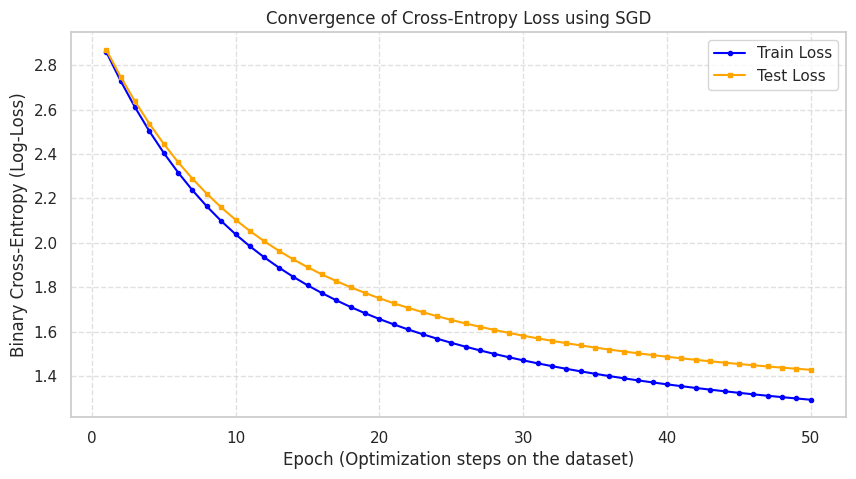

In [8]:
# SGDClassifier
clf_sgd = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.01, random_state=42)

# Training parameters
epocas = 50
classes = np.unique(y_train) #The 20 categories

train_losses = []
test_losses = []

# We train epoch by epoch using partial_fit.
for epoca in range(epocas):
    clf_sgd.partial_fit(X_train_vec, y_train, classes=classes)
    train_losses.append(log_loss(y_train, clf_sgd.predict_proba(X_train_vec),
                                 labels=clf_sgd.classes_))
    test_losses.append(log_loss(y_test, clf_sgd.predict_proba(X_test_vec),
                                labels=clf_sgd.classes_))

# Plot the loss curve.
fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
ax_loss.plot(range(1, epocas + 1), train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
ax_loss.plot(range(1, epocas + 1), test_losses, label='Test Loss', color='orange', marker='s', markersize=3)
ax_loss.set_title('Convergence of Cross-Entropy Loss using SGD')
ax_loss.set_xlabel('Epoch (Optimization steps on the dataset)')
ax_loss.set_ylabel('Binary Cross-Entropy (Log-Loss)')
ax_loss.legend()
ax_loss.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [9]:
y_pred_sgd = clf_sgd.predict(X_test_vec)

# **Proposed Improvement Implementation**

The proposed improvement is to change the text representation rather than the classifier.
Instead of the sparse TF-IDF matrix, documents are represented as dense vectors: a TF-IDF
weighted average of spaCy word embeddings. The classifier remains the same (logistic
regression trained with SGD), so any difference in performance is attributable to the
representation..

### Dense Representations with TF-IDF Weighted Averaging

In [10]:
# We extract the vocabulary and IDF weights from the previous vectorizer.
tfidf_pesos = TfidfVectorizer(ngram_range=(1, 1), min_df=2)
tfidf_pesos.fit(X_train)

vocabulario = tfidf_pesos.vocabulary_
pesos_idf = tfidf_pesos.idf_
DIM = nlp.vocab.vectors_length

def embeddings_ponderados(textos, batch_size=64):
    salida = []
    for doc in nlp.pipe(textos, batch_size=batch_size):
        vectores, pesos = [], []
        for token in doc:
            if token.is_alpha and not token.is_stop and token.has_vector:
                palabra = token.text.lower()
                idx = vocabulario.get(palabra)
                vectores.append(token.vector)
                pesos.append(pesos_idf[idx] if idx is not None else 1.0)
        if vectores:
            salida.append(np.average(vectores, axis=0, weights=pesos))
        else:
            salida.append(np.zeros(DIM))
    return np.vstack(salida)

print("Calculating spaCy embeddings (TF-IDF weighted average)...")
X_train_dense = embeddings_ponderados(X_train)
X_test_dense  = embeddings_ponderados(X_test)
print(X_train_dense.shape, X_test_dense.shape)

Calculating spaCy embeddings (TF-IDF weighted average)...
(13997, 300) (6000, 300)


In [11]:
# New classifier
clf_emb = SGDClassifier(loss='log_loss', learning_rate='constant',
                        eta0=0.01, random_state=42)

epocas = 50
classes = np.unique(y_train)
train_losses_emb, test_losses_emb = [], []

for epoca in range(epocas):
    clf_emb.partial_fit(X_train_dense, y_train, classes=classes)
    train_losses_emb.append(log_loss(y_train, clf_emb.predict_proba(X_train_dense),
                                     labels=clf_emb.classes_))
    test_losses_emb.append(log_loss(y_test, clf_emb.predict_proba(X_test_dense),
                                    labels=clf_emb.classes_))

y_pred_emb = clf_emb.predict(X_test_dense)


# **Evaluation**

Classification Report — Baseline (TF-IDF + SGD Logistic Regression)
                          precision    recall  f1-score   support

             alt.atheism       0.64      0.71      0.67       300
           comp.graphics       0.65      0.69      0.67       300
 comp.os.ms-windows.misc       0.71      0.69      0.70       300
comp.sys.ibm.pc.hardware       0.66      0.60      0.63       300
   comp.sys.mac.hardware       0.76      0.69      0.72       300
          comp.windows.x       0.79      0.77      0.78       300
            misc.forsale       0.69      0.78      0.73       300
               rec.autos       0.77      0.78      0.78       300
         rec.motorcycles       0.87      0.84      0.85       300
      rec.sport.baseball       0.84      0.88      0.86       300
        rec.sport.hockey       0.92      0.92      0.92       300
               sci.crypt       0.89      0.85      0.87       300
         sci.electronics       0.67      0.72      0.69       300
       

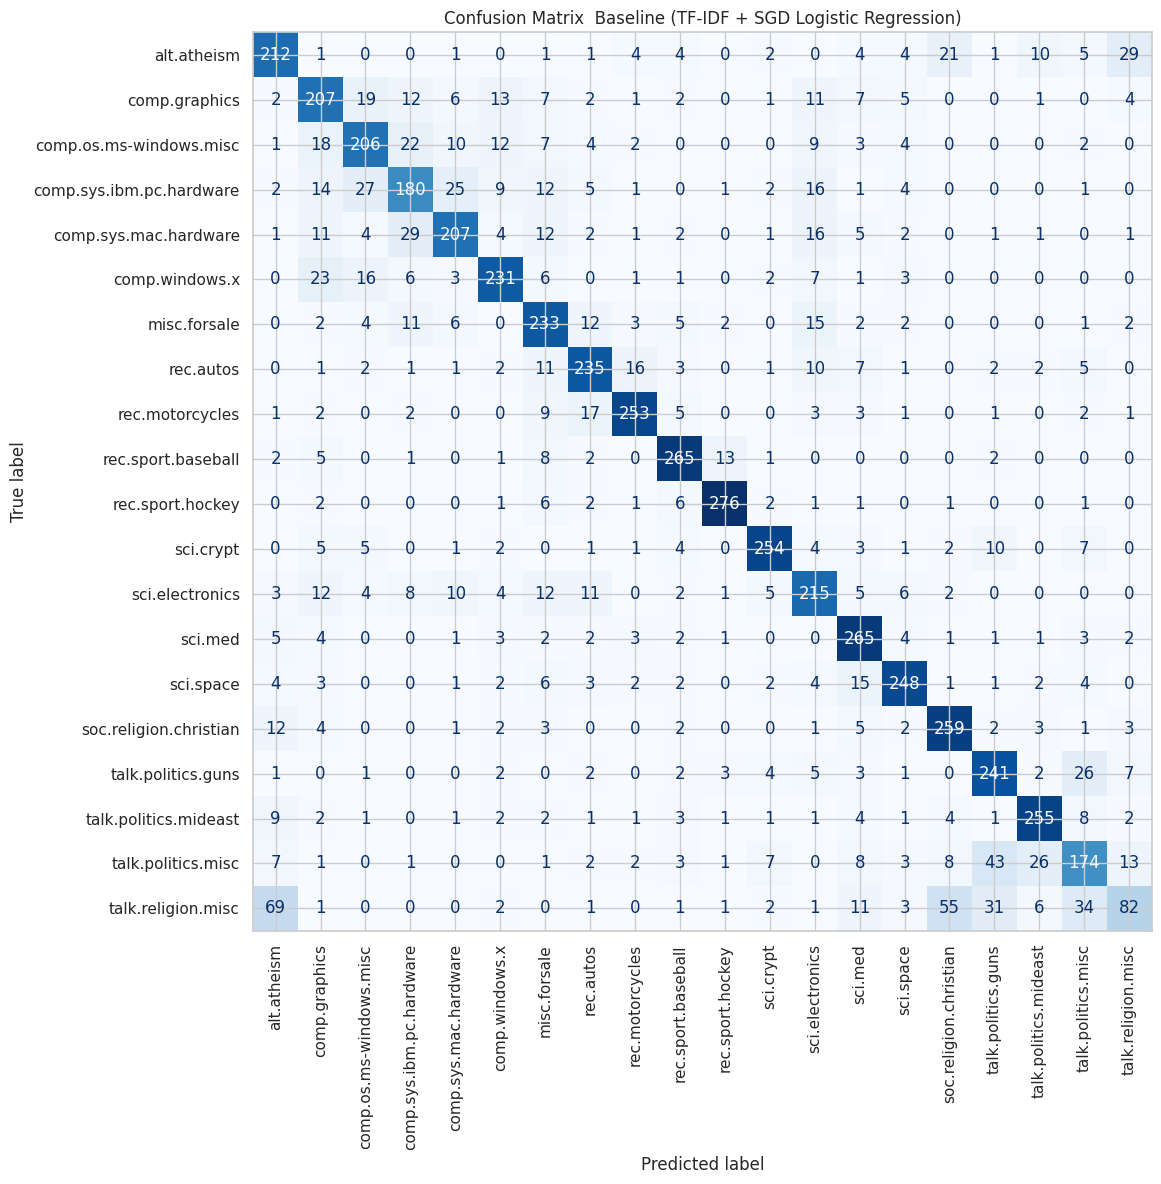

Classification Report — Improvement (spaCy embeddings + SGD Logistic Regression)
                          precision    recall  f1-score   support

             alt.atheism       0.52      0.48      0.50       300
           comp.graphics       0.66      0.50      0.57       300
 comp.os.ms-windows.misc       0.49      0.55      0.52       300
comp.sys.ibm.pc.hardware       0.47      0.60      0.53       300
   comp.sys.mac.hardware       0.59      0.26      0.36       300
          comp.windows.x       0.60      0.67      0.63       300
            misc.forsale       0.54      0.63      0.58       300
               rec.autos       0.64      0.72      0.68       300
         rec.motorcycles       0.67      0.71      0.69       300
      rec.sport.baseball       0.77      0.78      0.78       300
        rec.sport.hockey       0.82      0.79      0.81       300
               sci.crypt       0.64      0.76      0.69       300
         sci.electronics       0.63      0.50      0.56     

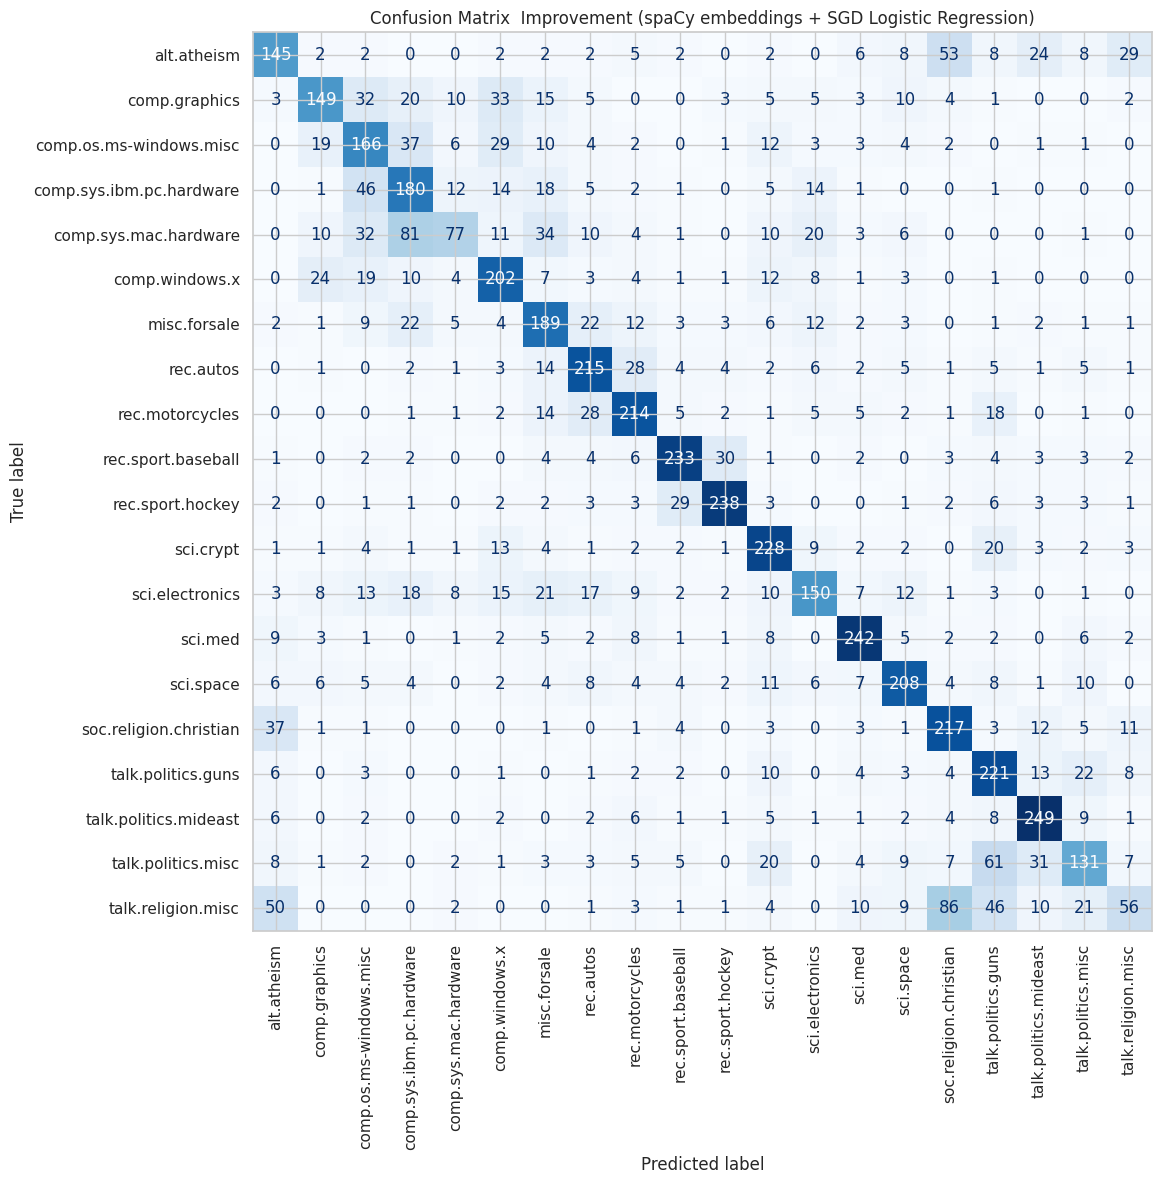

In [12]:
def evaluar(y_true, y_pred, nombre):
    print(f"Classification Report — {nombre}")
    print(classification_report(y_true, y_pred))

    fig, ax = plt.subplots(figsize=(12, 12))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, cmap='Blues', ax=ax,
        xticks_rotation='vertical', colorbar=False, values_format='d'
    )
    ax.set_title(f'Confusion Matrix  {nombre}')
    plt.tight_layout()
    plt.show()

evaluar(y_test, y_pred_sgd, "Baseline (TF-IDF + SGD Logistic Regression)")
evaluar(y_test, y_pred_emb, "Improvement (spaCy embeddings + SGD Logistic Regression)")

# **Comparison between the baseline and the proposed approach**

In [13]:
comparison = pd.DataFrame({
    'Model': ['Baseline: TF-IDF', 'Improvement: Weighted embeddings'],
    'Accuracy': [accuracy_score(y_test, y_pred_sgd), accuracy_score(y_test, y_pred_emb)],
    'F1 macro': [f1_score(y_test, y_pred_sgd, average='macro'),
                 f1_score(y_test, y_pred_emb, average='macro')],
})
display(comparison.round(4))

,Model,Accuracy,F1 macro
0,Baseline: TF-IDF,0.7497,0.7441
1,Improvement: Weighted embeddings,0.6183,0.6076


# **Results**

The baseline (TF-IDF) outperformed the proposed approach (spaCy embeddings)
on both metrics: accuracy 0.7547 vs 0.6248, and macro F1 0.7483 vs 0.6135. A reason of this is that embeddings map semantically related words to
nearby vectors. This is a disadvantage here, because categories such as alt.atheism,
soc.religion.christian and talk.religion.misc are distinguished by fine
lexical differences so the model gets confused predicting, and TF-IDF can recognize better those key words and have a better performance.